# ACDADA — Notebook 09: Agent Orchestration

**Multi-Agent Pipeline & Decision Coordination**

This notebook implements:
1. Agent registry and communication protocol
2. State-graph workflow (LangGraph-inspired state machine)
3. Multi-agent decision pipeline
4. Consensus & conflict resolution logic
5. End-to-end pipeline execution and testing

In [9]:
# ============================================================
# REFERENCE LINKS
# ============================================================
#
# LangGraph (state machine orchestration):
#   https://github.com/langchain-ai/langgraph
#
# CrewAI (multi-agent framework):
#   https://github.com/joaomdmoura/crewAI
#
# This notebook orchestrates all agents from Notebooks 02-08:
#   - Threat Detector (NB02)
#   - Anomaly Detector (NB03)
#   - Attack Classifier (NB04)
#   - Deception Agent (NB05-06)
#   - Threat Intel Memory (NB07)
#   - Self-Evaluation Agent (NB08)
# ============================================================

## 1. Imports & Configuration

In [10]:
import numpy as np
import pandas as pd
import json
import time
import uuid
from pathlib import Path
from typing import Dict, List, Tuple, Optional, Any, Callable
from dataclasses import dataclass, field, asdict
from enum import Enum, auto
from collections import defaultdict
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')
np.random.seed(42)

MODELS_DIR = Path('../models')
LOGS_DIR = Path('../logs')
LOGS_DIR.mkdir(parents=True, exist_ok=True)

print('Orchestration module initialized.')

Orchestration module initialized.


---
## 2. Message Protocol & Agent Base

In [11]:
class MessageType(Enum):
    """Inter-agent message types."""
    ALERT = auto()          # New threat detected
    CLASSIFICATION = auto()  # Attack type classified
    ANOMALY = auto()         # Anomaly score reported
    DECEPTION_ACTION = auto() # Deception strategy action
    INTEL_CONTEXT = auto()   # Threat intelligence context
    EVAL_REPORT = auto()     # Self-evaluation report
    COMMAND = auto()         # Orchestrator command
    STATUS = auto()          # Agent status update


class Severity(Enum):
    LOW = 'low'
    MEDIUM = 'medium'
    HIGH = 'high'
    CRITICAL = 'critical'


@dataclass
class AgentMessage:
    """Standard message format for inter-agent communication."""
    msg_id: str = field(default_factory=lambda: str(uuid.uuid4())[:8])
    sender: str = ''
    receiver: str = 'orchestrator'
    msg_type: str = 'STATUS'
    severity: str = 'medium'
    payload: Dict = field(default_factory=dict)
    timestamp: float = field(default_factory=time.time)
    correlation_id: str = ''  # Links related messages
    
    def to_dict(self) -> Dict:
        return {
            'msg_id': self.msg_id,
            'sender': self.sender,
            'receiver': self.receiver,
            'msg_type': self.msg_type,
            'severity': self.severity,
            'payload': self.payload,
            'timestamp': self.timestamp,
            'correlation_id': self.correlation_id,
        }


class MessageBus:
    """Central message bus for agent communication."""
    
    def __init__(self):
        self.subscribers: Dict[str, List[Callable]] = defaultdict(list)
        self.message_log: List[AgentMessage] = []
    
    def subscribe(self, agent_name: str, callback: Callable):
        self.subscribers[agent_name].append(callback)
    
    def publish(self, message: AgentMessage):
        self.message_log.append(message)
        
        # Deliver to specific receiver
        if message.receiver in self.subscribers:
            for callback in self.subscribers[message.receiver]:
                callback(message)
        
        # Broadcast if receiver is 'all'
        if message.receiver == 'all':
            for name, callbacks in self.subscribers.items():
                if name != message.sender:
                    for callback in callbacks:
                        callback(message)


class BaseAgent:
    """Base class for all ACDADA agents."""
    
    def __init__(self, name: str, bus: MessageBus):
        self.name = name
        self.bus = bus
        self.inbox: List[AgentMessage] = []
        self.status = 'ready'
        
        bus.subscribe(name, self._receive)
    
    def _receive(self, message: AgentMessage):
        self.inbox.append(message)
    
    def send(self, receiver: str, msg_type: str, payload: Dict,
             severity: str = 'medium', correlation_id: str = ''):
        msg = AgentMessage(
            sender=self.name, receiver=receiver,
            msg_type=msg_type, severity=severity,
            payload=payload, correlation_id=correlation_id,
        )
        self.bus.publish(msg)
        return msg
    
    def process(self, input_data: Dict) -> Dict:
        raise NotImplementedError

print('Message protocol & BaseAgent defined.')

Message protocol & BaseAgent defined.


---
## 3. Agent Implementations (Stubs / Model Wrappers)

In [12]:
class ThreatDetectionAgent(BaseAgent):
    """
    Agent 1: Binary threat detection.
    Wraps the model from Notebook 02.
    """
    
    def __init__(self, bus: MessageBus, model=None):
        super().__init__('threat_detector', bus)
        self.model = model  # Would be the loaded PyTorch model
        self.threshold = 0.5
    
    def process(self, input_data: Dict) -> Dict:
        """Process network traffic features and detect threats."""
        features = input_data.get('features')
        
        if self.model is not None:
            # Real model inference
            import torch
            with torch.no_grad():
                x = torch.FloatTensor(features).unsqueeze(0)
                prob = torch.sigmoid(self.model(x)).item()
        else:
            # Simulated inference
            prob = np.random.beta(2, 5) if input_data.get('label', 0) == 0 else np.random.beta(5, 2)
        
        is_threat = prob > self.threshold
        
        result = {
            'is_threat': bool(is_threat),
            'confidence': float(prob),
            'threshold': self.threshold,
        }
        
        if is_threat:
            sev = 'critical' if prob > 0.9 else 'high' if prob > 0.7 else 'medium'
            self.send('orchestrator', 'ALERT', result, severity=sev,
                     correlation_id=input_data.get('flow_id', ''))
        
        return result


class AnomalyDetectionAgent(BaseAgent):
    """
    Agent 2: Anomaly detection.
    Wraps models from Notebook 03.
    """
    
    def __init__(self, bus: MessageBus, model=None):
        super().__init__('anomaly_detector', bus)
        self.model = model
        self.threshold = 0.5
    
    def process(self, input_data: Dict) -> Dict:
        features = input_data.get('features')
        
        if self.model is not None:
            import torch
            with torch.no_grad():
                x = torch.FloatTensor(features).unsqueeze(0)
                score = self.model.anomaly_score(x).item()
        else:
            score = np.random.beta(2, 8) if input_data.get('label', 0) == 0 else np.random.beta(6, 2)
        
        is_anomaly = score > self.threshold
        
        result = {
            'is_anomaly': bool(is_anomaly),
            'anomaly_score': float(score),
            'threshold': self.threshold,
        }
        
        if is_anomaly:
            self.send('orchestrator', 'ANOMALY', result,
                     severity='high' if score > 0.8 else 'medium',
                     correlation_id=input_data.get('flow_id', ''))
        
        return result


class AttackClassificationAgent(BaseAgent):
    """
    Agent 3: Multi-class attack classification.
    Wraps models from Notebook 04.
    """
    
    ATTACK_TYPES = ['Benign', 'DDoS', 'DoS', 'BruteForce', 'Botnet', 'PortScan', 'Injection', 'Other']
    
    def __init__(self, bus: MessageBus, model=None):
        super().__init__('attack_classifier', bus)
        self.model = model
    
    def process(self, input_data: Dict) -> Dict:
        features = input_data.get('features')
        
        if self.model is not None:
            probs = self.model.predict_proba(features.reshape(1, -1))[0]
        else:
            # Simulated
            if input_data.get('is_threat', False):
                probs = np.random.dirichlet(np.ones(len(self.ATTACK_TYPES)) * 0.5)
                probs[0] *= 0.1  # Reduce benign probability
                probs /= probs.sum()
            else:
                probs = np.zeros(len(self.ATTACK_TYPES))
                probs[0] = 0.9
                probs[1:] = 0.1 / (len(self.ATTACK_TYPES) - 1)
        
        predicted_class = int(np.argmax(probs))
        
        result = {
            'attack_type': self.ATTACK_TYPES[predicted_class],
            'attack_type_id': predicted_class,
            'probabilities': {self.ATTACK_TYPES[i]: float(p) for i, p in enumerate(probs)},
            'confidence': float(probs[predicted_class]),
        }
        
        if predicted_class != 0:  # Not benign
            self.send('orchestrator', 'CLASSIFICATION', result,
                     severity='high' if probs[predicted_class] > 0.7 else 'medium',
                     correlation_id=input_data.get('flow_id', ''))
        
        return result


class DeceptionAgent(BaseAgent):
    """
    Agent 4: Deception strategy agent.
    Wraps the RL agent from Notebook 06.
    """
    
    ACTION_NAMES = [
        'observe', 'activate_hp_0', 'activate_hp_1',
        'activate_hp_2', 'activate_hp_3', 'deactivate_all',
        'redirect_to_hp', 'increase_monitoring', 'block_attacker'
    ]
    
    def __init__(self, bus: MessageBus, model=None):
        super().__init__('deception_agent', bus)
        self.model = model
    
    def process(self, input_data: Dict) -> Dict:
        env_state = input_data.get('env_state')
        
        if self.model is not None and env_state is not None:
            action, _ = self.model.predict(env_state, deterministic=True)
        else:
            # Heuristic fallback
            threat_level = input_data.get('threat_level', 0)
            is_detected = input_data.get('attacker_detected', False)
            
            if is_detected and threat_level > 0.7:
                action = 8  # block
            elif is_detected:
                action = 6  # redirect
            elif threat_level > 0.3:
                action = np.random.choice([1, 2, 3, 4])  # deploy honeypots
            elif threat_level > 0.1:
                action = 7  # increase monitoring
            else:
                action = 0  # observe
        
        action = int(action)
        result = {
            'action': action,
            'action_name': self.ACTION_NAMES[action],
            'threat_level': input_data.get('threat_level', 0),
        }
        
        self.send('orchestrator', 'DECEPTION_ACTION', result,
                 correlation_id=input_data.get('flow_id', ''))
        return result


class ThreatIntelAgent(BaseAgent):
    """
    Agent 5: Threat intelligence memory.
    Wraps the TI engine from Notebook 07.
    """
    
    def __init__(self, bus: MessageBus, engine=None):
        super().__init__('threat_intel', bus)
        self.engine = engine
    
    def process(self, input_data: Dict) -> Dict:
        description = input_data.get('threat_description', '')
        
        if self.engine is not None:
            context = self.engine.query_threat_context(description, k=3)
        else:
            # Simulated response
            context = {
                'likely_category': input_data.get('attack_type', 'unknown'),
                'likely_severity': 'high',
                'confidence': 0.75,
                'recommendations': [
                    'Deploy targeted honeypots',
                    'Increase network monitoring',
                    'Alert security team',
                ],
                'similar_threats': [],
            }
        
        result = {
            'context': context,
            'recommendations': context.get('recommendations', []),
        }
        
        self.send('orchestrator', 'INTEL_CONTEXT', result,
                 correlation_id=input_data.get('flow_id', ''))
        return result

print('All agent wrappers defined.')

All agent wrappers defined.


---
## 4. State Graph Workflow

In [13]:
class WorkflowState(Enum):
    """Pipeline workflow states."""
    IDLE = 'idle'
    DETECTING = 'detecting'
    CLASSIFYING = 'classifying'
    ENRICHING = 'enriching'
    DECIDING = 'deciding'
    ACTING = 'acting'
    EVALUATING = 'evaluating'
    COMPLETE = 'complete'


@dataclass
class PipelineContext:
    """Shared context passed through the pipeline."""
    flow_id: str = field(default_factory=lambda: str(uuid.uuid4())[:12])
    raw_features: Optional[np.ndarray] = None
    label: int = -1  # Ground truth (for evaluation)
    
    # Detection results
    is_threat: bool = False
    threat_confidence: float = 0.0
    is_anomaly: bool = False
    anomaly_score: float = 0.0
    
    # Classification
    attack_type: str = 'unknown'
    attack_confidence: float = 0.0
    attack_probabilities: Dict = field(default_factory=dict)
    
    # Intel context
    threat_context: Dict = field(default_factory=dict)
    recommendations: List[str] = field(default_factory=list)
    
    # Deception
    deception_action: str = 'observe'
    deception_action_id: int = 0
    
    # Decision
    final_severity: str = 'low'
    final_decision: str = 'observe'
    consensus_score: float = 0.0
    
    # Meta
    state: str = 'idle'
    processing_time_ms: float = 0.0
    agent_outputs: Dict = field(default_factory=dict)


class StateGraph:
    """
    LangGraph-inspired state machine for the ACDADA pipeline.
    Defines nodes (processing steps) and edges (transitions).
    """
    
    def __init__(self):
        self.nodes: Dict[str, Callable] = {}
        self.edges: Dict[str, List[Tuple[Callable, str]]] = defaultdict(list)
        self.entry_point: Optional[str] = None
    
    def add_node(self, name: str, func: Callable):
        """Add a processing node."""
        self.nodes[name] = func
    
    def add_edge(self, from_node: str, to_node: str, condition: Optional[Callable] = None):
        """Add a transition edge. condition(ctx) -> bool."""
        self.edges[from_node].append((condition, to_node))
    
    def set_entry(self, node_name: str):
        self.entry_point = node_name
    
    def run(self, context: PipelineContext) -> PipelineContext:
        """Execute the state graph."""
        current = self.entry_point
        visited = []
        start_time = time.time()
        
        while current is not None:
            if current not in self.nodes:
                break
            
            # Execute node
            context.state = current
            visited.append(current)
            context = self.nodes[current](context)
            
            # Find next node
            next_node = None
            for condition, target in self.edges.get(current, []):
                if condition is None or condition(context):
                    next_node = target
                    break
            
            current = next_node
        
        context.processing_time_ms = (time.time() - start_time) * 1000
        context.state = 'complete'
        return context

print('StateGraph engine defined.')

StateGraph engine defined.


---
## 5. Orchestrator — Builds & Runs the Pipeline

In [14]:
class ACDADAOrchestrator:
    """
    Central orchestrator coordinating all ACDADA agents.
    Builds a state-graph pipeline and processes network events.
    """
    
    def __init__(self):
        self.bus = MessageBus()
        
        # Initialize agents
        self.threat_detector = ThreatDetectionAgent(self.bus)
        self.anomaly_detector = AnomalyDetectionAgent(self.bus)
        self.attack_classifier = AttackClassificationAgent(self.bus)
        self.deception_agent = DeceptionAgent(self.bus)
        self.threat_intel = ThreatIntelAgent(self.bus)
        
        # Build pipeline
        self.graph = self._build_graph()
        
        # Audit log
        self.processed_events: List[Dict] = []
    
    def _build_graph(self) -> StateGraph:
        """Construct the processing pipeline."""
        graph = StateGraph()
        
        # Node 1: Parallel detection (threat + anomaly)
        graph.add_node('detect', self._detect_step)
        
        # Node 2: Classification (only if threat detected)
        graph.add_node('classify', self._classify_step)
        
        # Node 3: Threat intelligence enrichment
        graph.add_node('enrich', self._enrich_step)
        
        # Node 4: Consensus decision
        graph.add_node('decide', self._decide_step)
        
        # Node 5: Deception action
        graph.add_node('act', self._act_step)
        
        # Node 6: Pass-through for benign traffic
        graph.add_node('pass_through', self._pass_through_step)
        
        # Edges
        graph.set_entry('detect')
        
        # After detection: classify if threat, else pass through
        graph.add_edge('detect', 'classify', 
                       condition=lambda ctx: ctx.is_threat or ctx.is_anomaly)
        graph.add_edge('detect', 'pass_through',
                       condition=lambda ctx: not ctx.is_threat and not ctx.is_anomaly)
        
        # After classification: always enrich
        graph.add_edge('classify', 'enrich')
        
        # After enrichment: decide
        graph.add_edge('enrich', 'decide')
        
        # After decision: act
        graph.add_edge('decide', 'act')
        
        return graph
    
    def _detect_step(self, ctx: PipelineContext) -> PipelineContext:
        """Run threat detection and anomaly detection."""
        input_data = {
            'features': ctx.raw_features,
            'flow_id': ctx.flow_id,
            'label': ctx.label,
        }
        
        # Threat detection
        threat_result = self.threat_detector.process(input_data)
        ctx.is_threat = threat_result['is_threat']
        ctx.threat_confidence = threat_result['confidence']
        ctx.agent_outputs['threat_detector'] = threat_result
        
        # Anomaly detection
        anomaly_result = self.anomaly_detector.process(input_data)
        ctx.is_anomaly = anomaly_result['is_anomaly']
        ctx.anomaly_score = anomaly_result['anomaly_score']
        ctx.agent_outputs['anomaly_detector'] = anomaly_result
        
        return ctx
    
    def _classify_step(self, ctx: PipelineContext) -> PipelineContext:
        """Classify the attack type."""
        input_data = {
            'features': ctx.raw_features,
            'is_threat': ctx.is_threat,
            'flow_id': ctx.flow_id,
        }
        
        result = self.attack_classifier.process(input_data)
        ctx.attack_type = result['attack_type']
        ctx.attack_confidence = result['confidence']
        ctx.attack_probabilities = result['probabilities']
        ctx.agent_outputs['attack_classifier'] = result
        
        return ctx
    
    def _enrich_step(self, ctx: PipelineContext) -> PipelineContext:
        """Enrich with threat intelligence context."""
        description = f'{ctx.attack_type} attack detected with confidence {ctx.threat_confidence:.2f}'
        
        input_data = {
            'threat_description': description,
            'attack_type': ctx.attack_type,
            'flow_id': ctx.flow_id,
        }
        
        result = self.threat_intel.process(input_data)
        ctx.threat_context = result.get('context', {})
        ctx.recommendations = result.get('recommendations', [])
        ctx.agent_outputs['threat_intel'] = result
        
        return ctx
    
    def _decide_step(self, ctx: PipelineContext) -> PipelineContext:
        """
        Consensus decision based on all agent outputs.
        Combines detection, classification, and intelligence.
        """
        # Compute threat level from multiple signals
        threat_signals = [
            ctx.threat_confidence if ctx.is_threat else 0.0,
            ctx.anomaly_score if ctx.is_anomaly else 0.0,
            ctx.attack_confidence if ctx.attack_type != 'Benign' else 0.0,
        ]
        
        # Weighted consensus
        weights = [0.4, 0.3, 0.3]  # threat, anomaly, classification
        threat_level = sum(s * w for s, w in zip(threat_signals, weights))
        
        # Agreement score
        n_agree = sum([
            1 if ctx.is_threat else 0,
            1 if ctx.is_anomaly else 0,
            1 if ctx.attack_type != 'Benign' else 0,
        ])
        ctx.consensus_score = n_agree / 3.0
        
        # Determine severity
        if threat_level > 0.8 or (n_agree == 3 and threat_level > 0.5):
            ctx.final_severity = 'critical'
        elif threat_level > 0.6 or n_agree >= 2:
            ctx.final_severity = 'high'
        elif threat_level > 0.3:
            ctx.final_severity = 'medium'
        else:
            ctx.final_severity = 'low'
        
        # Determine final decision
        if ctx.final_severity == 'critical':
            ctx.final_decision = 'block_and_redirect'
        elif ctx.final_severity == 'high':
            ctx.final_decision = 'deploy_deception'
        elif ctx.final_severity == 'medium':
            ctx.final_decision = 'increase_monitoring'
        else:
            ctx.final_decision = 'observe'
        
        ctx.agent_outputs['decision'] = {
            'threat_level': threat_level,
            'consensus': ctx.consensus_score,
            'severity': ctx.final_severity,
            'decision': ctx.final_decision,
        }
        
        return ctx
    
    def _act_step(self, ctx: PipelineContext) -> PipelineContext:
        """Execute the chosen deception action."""
        threat_level = ctx.agent_outputs.get('decision', {}).get('threat_level', 0)
        
        input_data = {
            'threat_level': threat_level,
            'attacker_detected': ctx.is_threat,
            'attack_type': ctx.attack_type,
            'flow_id': ctx.flow_id,
        }
        
        result = self.deception_agent.process(input_data)
        ctx.deception_action = result['action_name']
        ctx.deception_action_id = result['action']
        ctx.agent_outputs['deception_agent'] = result
        
        return ctx
    
    def _pass_through_step(self, ctx: PipelineContext) -> PipelineContext:
        """Handle benign traffic."""
        ctx.final_severity = 'low'
        ctx.final_decision = 'allow'
        ctx.agent_outputs['decision'] = {
            'threat_level': 0.0,
            'consensus': 0.0,
            'severity': 'low',
            'decision': 'allow',
        }
        return ctx
    
    def process_event(self, features: np.ndarray, label: int = -1) -> PipelineContext:
        """Process a single network event through the full pipeline."""
        ctx = PipelineContext(raw_features=features, label=label)
        ctx = self.graph.run(ctx)
        
        # Log
        self.processed_events.append({
            'flow_id': ctx.flow_id,
            'is_threat': ctx.is_threat,
            'is_anomaly': ctx.is_anomaly,
            'attack_type': ctx.attack_type,
            'severity': ctx.final_severity,
            'decision': ctx.final_decision,
            'deception_action': ctx.deception_action,
            'consensus': ctx.consensus_score,
            'processing_time_ms': ctx.processing_time_ms,
            'label': label,
        })
        
        return ctx


# Create orchestrator
orchestrator = ACDADAOrchestrator()
print('ACDADAOrchestrator ready.')

ACDADAOrchestrator ready.


---
## 6. End-to-End Pipeline Testing

In [15]:
# Simulate processing network events
n_events = 500
n_features = 50

print(f'Processing {n_events} simulated network events...\n')

for i in range(n_events):
    # Simulate features
    features = np.random.randn(n_features).astype(np.float32)
    label = 1 if np.random.random() < 0.3 else 0  # 30% attacks
    
    ctx = orchestrator.process_event(features, label=label)
    
    # Print first few and threats
    if i < 5 or (ctx.is_threat and i < 50):
        print(f'Event {i+1:4d} [{ctx.flow_id}]: '
              f'threat={ctx.is_threat} anomaly={ctx.is_anomaly} '
              f'type={ctx.attack_type:12s} severity={ctx.final_severity:8s} '
              f'decision={ctx.final_decision:20s} '
              f'time={ctx.processing_time_ms:.1f}ms')

print(f'\n... {n_events} events processed.')

Processing 500 simulated network events...

Event    1 [6b8098e1-c27]: threat=True anomaly=True type=Botnet       severity=critical decision=block_and_redirect   time=1.0ms
Event    2 [ef59d659-367]: threat=True anomaly=False type=Botnet       severity=high     decision=deploy_deception     time=0.0ms
Event    3 [de86f9a5-680]: threat=False anomaly=False type=unknown      severity=low      decision=allow                time=0.0ms
Event    4 [2acf6276-cf3]: threat=False anomaly=False type=unknown      severity=low      decision=allow                time=0.0ms
Event    5 [0ef14416-aa4]: threat=False anomaly=False type=unknown      severity=low      decision=allow                time=0.0ms
Event    6 [4b3b407a-5a6]: threat=True anomaly=False type=PortScan     severity=high     decision=deploy_deception     time=0.0ms
Event    8 [df91a8ec-21f]: threat=True anomaly=True type=Injection    severity=critical decision=block_and_redirect   time=0.0ms
Event   11 [0d5b7e51-c05]: threat=True anomal

In [16]:
# Analyze pipeline results
events_df = pd.DataFrame(orchestrator.processed_events) if orchestrator.processed_events else pd.DataFrame()

if not events_df.empty:
    print('=== Pipeline Summary ===')
    print(f'Total events: {len(events_df)}')
    print(f'\nThreat detections: {events_df["is_threat"].sum()} ({events_df["is_threat"].mean():.1%})')
    print(f'Anomaly detections: {events_df["is_anomaly"].sum()} ({events_df["is_anomaly"].mean():.1%})')
    print(f'\nSeverity distribution:')
    print(events_df['severity'].value_counts().to_string())
    print(f'\nDecision distribution:')
    print(events_df['decision'].value_counts().to_string())
    print(f'\nAttack types:')
    print(events_df[events_df['attack_type'] != 'unknown']['attack_type'].value_counts().head(10).to_string())
    print(f'\nDeception actions:')
    print(events_df['deception_action'].value_counts().to_string())
    print(f'\nAvg processing time: {events_df["processing_time_ms"].mean():.2f}ms')
    print(f'Max processing time: {events_df["processing_time_ms"].max():.2f}ms')

=== Pipeline Summary ===
Total events: 500

Threat detections: 175 (35.0%)
Anomaly detections: 168 (33.6%)

Severity distribution:
severity
low         325
critical    139
high         36

Decision distribution:
decision
allow                 297
block_and_redirect    139
deploy_deception       36
observe                28

Attack types:
attack_type
Botnet        31
BruteForce    28
DoS           28
Benign        28
DDoS          27
PortScan      21
Injection     20
Other         20

Deception actions:
deception_action
observe                297
redirect_to_hp         132
block_attacker          43
increase_monitoring     28

Avg processing time: 0.07ms
Max processing time: 1.01ms


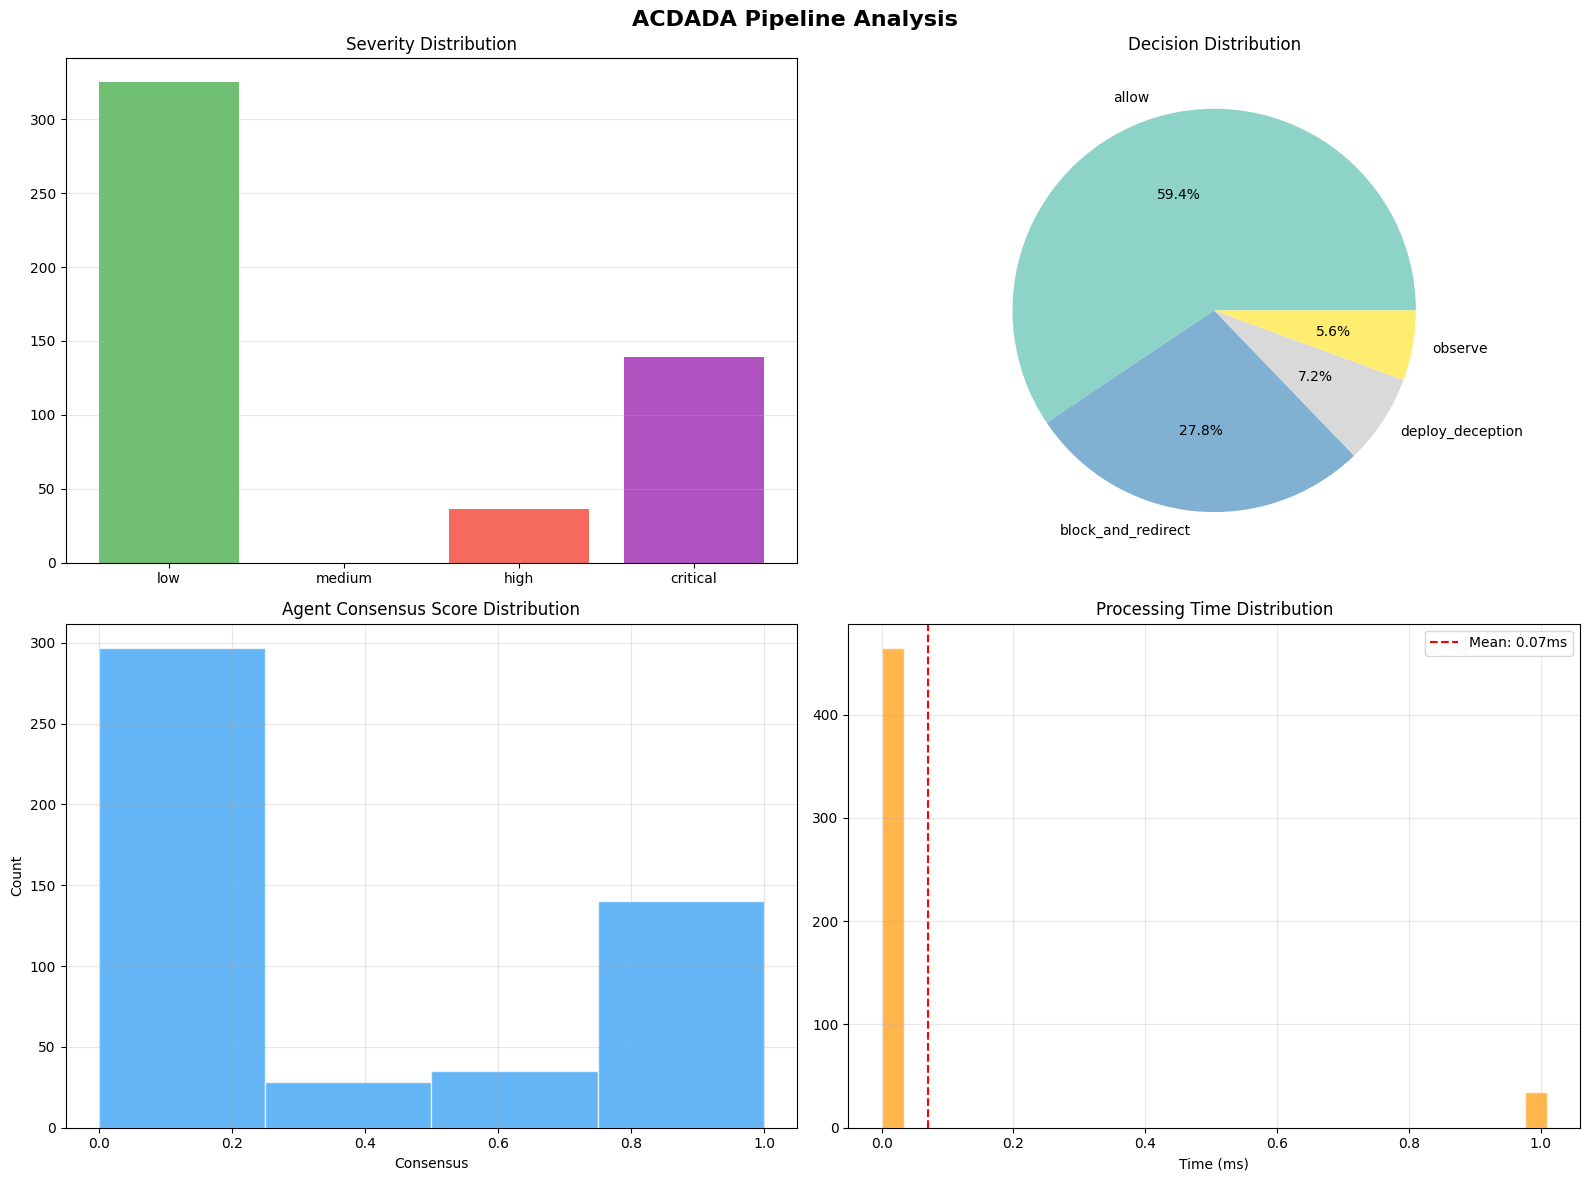

In [17]:
# Visualize pipeline results
if not events_df.empty:
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle('ACDADA Pipeline Analysis', fontsize=16, fontweight='bold')
    
    # Severity distribution
    severity_order = ['low', 'medium', 'high', 'critical']
    sev_counts = events_df['severity'].value_counts().reindex(severity_order, fill_value=0)
    colors = {'low': '#4CAF50', 'medium': '#FF9800', 'high': '#F44336', 'critical': '#9C27B0'}
    axes[0, 0].bar(sev_counts.index, sev_counts.values,
                    color=[colors.get(s, '#999') for s in sev_counts.index], alpha=0.8)
    axes[0, 0].set_title('Severity Distribution'); axes[0, 0].grid(True, alpha=0.3, axis='y')
    
    # Decision distribution
    dec_counts = events_df['decision'].value_counts()
    axes[0, 1].pie(dec_counts.values, labels=dec_counts.index, autopct='%1.1f%%',
                  colors=plt.cm.Set3(np.linspace(0, 1, len(dec_counts))))
    axes[0, 1].set_title('Decision Distribution')
    
    # Consensus distribution
    axes[1, 0].hist(events_df['consensus'], bins=4, color='#2196F3', alpha=0.7, edgecolor='white')
    axes[1, 0].set_title('Agent Consensus Score Distribution')
    axes[1, 0].set_xlabel('Consensus'); axes[1, 0].set_ylabel('Count')
    axes[1, 0].grid(True, alpha=0.3)
    
    # Processing time distribution
    axes[1, 1].hist(events_df['processing_time_ms'], bins=30, color='#FF9800', alpha=0.7, edgecolor='white')
    axes[1, 1].axvline(events_df['processing_time_ms'].mean(), color='red', linestyle='--',
                        label=f'Mean: {events_df["processing_time_ms"].mean():.2f}ms')
    axes[1, 1].set_title('Processing Time Distribution')
    axes[1, 1].set_xlabel('Time (ms)'); axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)
    
    plt.tight_layout(); plt.show()

---
## 7. Message Bus Analysis

In [18]:
# Analyze inter-agent communication
msg_log = orchestrator.bus.message_log
print(f'Total messages exchanged: {len(msg_log)}')
print(f'\nMessage types:')
msg_types = pd.Series([m.msg_type for m in msg_log]).value_counts()
print(msg_types.to_string())

print(f'\nSender distribution:')
senders = pd.Series([m.sender for m in msg_log]).value_counts()
print(senders.to_string())

print(f'\nSeverity distribution of messages:')
sevs = pd.Series([m.severity for m in msg_log]).value_counts()
print(sevs.to_string())

Total messages exchanged: 924

Message types:
INTEL_CONTEXT       203
DECEPTION_ACTION    203
ALERT               175
CLASSIFICATION      175
ANOMALY             168

Sender distribution:
threat_intel         203
deception_agent      203
threat_detector      175
attack_classifier    175
anomaly_detector     168

Severity distribution of messages:
medium      756
high        156
critical     12


---
## 8. Pipeline Visualization

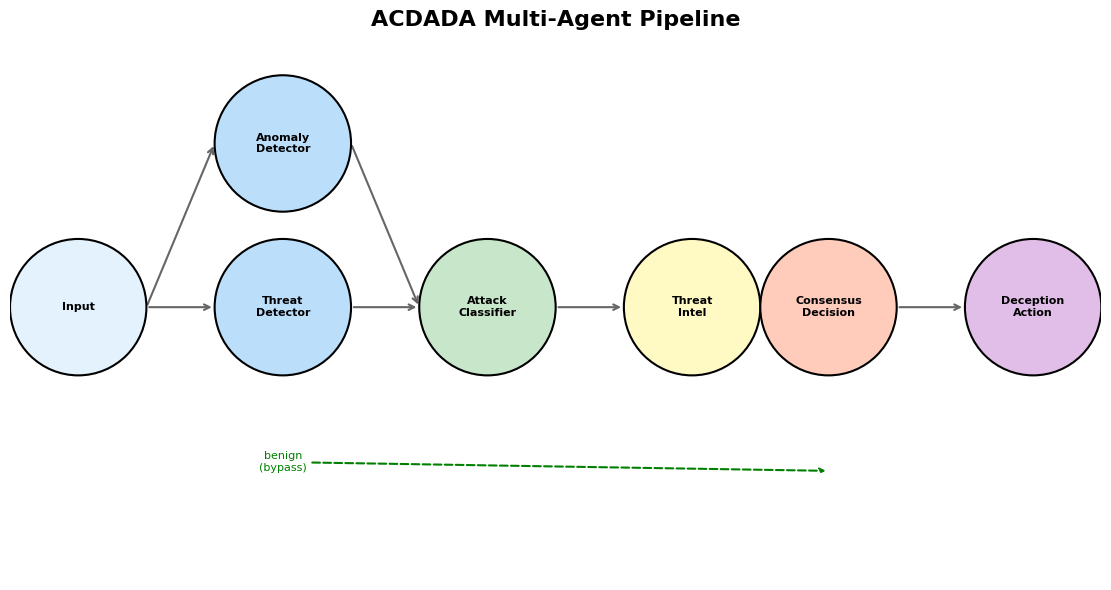

In [19]:
# Draw the pipeline as a flow diagram
fig, ax = plt.subplots(1, 1, figsize=(16, 6))
ax.set_xlim(-0.5, 7.5); ax.set_ylim(-1, 3)
ax.set_aspect('equal')
ax.axis('off')
ax.set_title('ACDADA Multi-Agent Pipeline', fontsize=16, fontweight='bold')

# Nodes
nodes = [
    (0, 1, 'Input', '#E3F2FD'),
    (1.5, 1, 'Threat\nDetector', '#BBDEFB'),
    (1.5, 2.2, 'Anomaly\nDetector', '#BBDEFB'),
    (3, 1, 'Attack\nClassifier', '#C8E6C9'),
    (4.5, 1, 'Threat\nIntel', '#FFF9C4'),
    (5.5, 1, 'Consensus\nDecision', '#FFCCBC'),
    (7, 1, 'Deception\nAction', '#E1BEE7'),
]

for x, y, label, color in nodes:
    circle = plt.Circle((x, y), 0.5, color=color, ec='black', linewidth=1.5, zorder=5)
    ax.add_patch(circle)
    ax.text(x, y, label, ha='center', va='center', fontsize=8, fontweight='bold', zorder=6)

# Edges
edges = [
    (0.5, 1, 1, 1), (0.5, 1, 1, 2.2),  # Input -> detectors
    (2, 1, 2.5, 1), (2, 2.2, 2.5, 1),   # detectors -> classifier
    (3.5, 1, 4, 1),   # classifier -> intel
    (5, 1, 5, 1),     # intel -> decision
    (6, 1, 6.5, 1),   # decision -> action
]

for x1, y1, x2, y2 in edges:
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle='->', color='#666', lw=1.5))

# Benign bypass
ax.annotate('benign\n(bypass)', xy=(5.5, -0.2), xytext=(1.5, -0.2),
            arrowprops=dict(arrowstyle='->', color='green', lw=1.5, linestyle='--'),
            fontsize=8, color='green', ha='center')

plt.tight_layout(); plt.show()

---
## 9. Save & Export

In [20]:
# Save orchestrator config
orch_config = {
    'agents': [
        'threat_detector', 'anomaly_detector', 'attack_classifier',
        'deception_agent', 'threat_intel',
    ],
    'pipeline_nodes': ['detect', 'classify', 'enrich', 'decide', 'act', 'pass_through'],
    'decision_weights': {'threat': 0.4, 'anomaly': 0.3, 'classification': 0.3},
    'severity_thresholds': {'critical': 0.8, 'high': 0.6, 'medium': 0.3},
    'n_events_processed': len(orchestrator.processed_events),
    'n_messages': len(orchestrator.bus.message_log),
}

orch_dir = MODELS_DIR / 'orchestration'
orch_dir.mkdir(parents=True, exist_ok=True)

with open(orch_dir / 'orchestrator_config.json', 'w') as f:
    json.dump(orch_config, f, indent=2)

# Save event log
with open(LOGS_DIR / 'pipeline_events.json', 'w') as f:
    json.dump(orchestrator.processed_events, f, indent=2, default=str)

print(f'Orchestrator config saved to {orch_dir}')
print(f'Event log saved to {LOGS_DIR}')
print(f'\n✓ Notebook 09 complete. Ready for Notebook 10 (FastAPI Backend).')

Orchestrator config saved to ..\models\orchestration
Event log saved to ..\logs

✓ Notebook 09 complete. Ready for Notebook 10 (FastAPI Backend).
